# Recidivism and Prison Education Policies

This notebook estimates the impact of prison education policies on recidivism using inmate-level NCRP data.

## Research Question
Does expanded access to prison education reduce the probability that an individual recidivates within two years of release?

## Empirical Strategy
We use a Difference-in-Differences (DiD) framework exploiting the 2016 expansion of Pell Grant eligibility for incarcerated individuals.

The basic model compares changes in recidivism rates before and after 2016 between states that participated in the Pell experimental expansion and those that did not.

## Outcome Variable
within_2_yrs  
Indicator equal to 1 if an individual returns to prison within two years of release.

## Treatment Variable
PELL_2016  
Indicator equal to 1 if the state participated in the 2016 Second Chance Pell experimental expansion.

## Sample
The dataset consists of inmate-level prison release records across U.S. states between 2005 and 2018.

Additional robustness checks will consider restrictions on sentence length, age, and repeat incarceration history.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [2]:
df = pd.read_csv("clean_recidivism.csv")

df.shape

/var/folders/rq/6gkwkw8n79d9pw5r3y76nfqc0000gn/T/ipykernel_85199/1379879146.py:1: DtypeWarning: Columns (0: policy_tier) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("clean_recidivism.csv")


(11625398, 31)

## Construct Difference-in-Differences Variables

We define the treatment group (states participating in the Second Chance Pell expansion),  
the post-policy period (2016 onward), and their interaction.

In [3]:
df["post"] = (df["RELEASEYR"] >= 2016).astype(int)

df["treated"] = df["PELL_2016"]

df["post_treated"] = df["post"] * df["treated"]

In [4]:
df[["RELEASEYR", "PELL_2016", "post", "treated", "post_treated"]].head()

,RELEASEYR,PELL_2016,post,treated,post_treated
0,2013,1,0,1,0
1,2009,1,0,1,0
2,2016,1,1,1,1
3,2017,1,1,1,1
4,2013,1,0,1,0


In [5]:
df.groupby(["post", "treated"])["within_2_yrs"].mean()

post  treated
0     0          0.292563
      1          0.359699
1     0          0.278422
      1          0.241961
Name: within_2_yrs, dtype: float64

## 1. Difference-in-Differences Regression
We estimate the effect of the Pell Grant expansion on recidivism.

In [6]:
model = smf.ols("within_2_yrs ~ treated + post + post_treated", data=df).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           within_2_yrs   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                 2.923e+04
Date:                Mon, 27 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:28:48   Log-Likelihood:            -7.6895e+06
No. Observations:            11625398   AIC:                         1.538e+07
Df Residuals:                11625394   BIC:                         1.538e+07
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.2926      0.000   1017.162      0.000       0.292       0.293
treated          0.0671      0.000    200.639      0.000       0.066       0.068
post            -0.0141      0.001    -18.756      0.000      -0.016      -0.013
post_treated    -0.1036      0.001   -114.546      0.000      -0.105      -0.102
==============================================================================
Omnibus:                 78272669.470   Durbin-Watson:                   1.887
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          2012486.939
Skew:                           0.708   Prob(JB):                         0.00
Kurtosis:                       1.535   Cond. No.                         10.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Initial Difference-in-Differences Results

We first estimate a baseline Difference-in-Differences (DID) model to assess the relationship between Pell Grant participation in prisons and recidivism within two years of release.

The key coefficient is the interaction term `post_treated`, which captures the difference in recidivism changes between treated and non-treated states after the policy period.

The results show:

- **post_treated = -0.1036

This suggests that after 2016, states participating in the Pell program experienced approximately a **10.36 percentage point lower probability of recidivism within two years of release** relative to non-participating states.

Given that the baseline recidivism rate is approximately **29.3%**, this corresponds to a substantial relative reduction (about 35%).

However, this baseline specification does not control for:

- persistent differences in recidivism levels across states
- nationwide changes in recidivism trends over time

States differ significantly in sentencing practices, parole policies, and correctional systems, all of which can influence recidivism. Similarly, national factors such as criminal justice reforms or economic conditions may affect recidivism rates over time.

To account for these potential confounding factors, we next estimate a **Difference-in-Differences model with state and year fixed effects**. This specification controls for time-invariant differences across states and common temporal shocks, allowing for a more credible estimate of the policy effect.

## 2. DID Regression with State and Year Fixed Effects

In [7]:
model_fe = smf.ols(
    "within_2_yrs ~ post_treated + C(STATE_NAME) + C(RELEASEYR)", data=df
).fit()

model_fe.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           within_2_yrs   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                     7460.
Date:                Mon, 27 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:37:54   Log-Likelihood:            -7.4387e+06
No. Observations:            11625398   AIC:                         1.488e+07
Df Residuals:                11625316   BIC:                         1.488e+07
Df Model:                          81                                         
Covariance Type:            nonrobust                                         
=========================================================================================================
                                            coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
Intercept                                 0.2349      0.008     30.175      0.000       0.220       0.250
C(STATE_NAME)[T.Arizona]                 -0.0579      0.001    -40.520      0.000      -0.061      -0.055
C(STATE_NAME)[T.California]               0.1544      0.001    126.291      0.000       0.152       0.157
C(STATE_NAME)[T.Colorado]                 0.0633      0.002     39.195      0.000       0.060       0.066
C(STATE_NAME)[T.Delaware]                 0.1526      0.002     72.075      0.000       0.148       0.157
C(STATE_NAME)[T.District of Columbia]     0.0302      0.002     12.274      0.000       0.025       0.035
C(STATE_NAME)[T.Florida]                 -0.1021      0.001    -78.687      0.000      -0.105      -0.100
C(STATE_NAME)[T.Georgia]                 -0.0853      0.001    -63.153      0.000      -0.088      -0.083
C(STATE_NAME)[T.Illinois]                 0.0324      0.001     25.112      0.000       0.030       0.035
C(STATE_NAME)[T.Indiana]                  0.0035      0.001      2.391      0.017       0.001       0.006
C(STATE_NAME)[T.Iowa]                     0.0132      0.002      6.396      0.000       0.009       0.017
C(STATE_NAME)[T.Kentucky]                -0.0325      0.001    -22.790      0.000      -0.035      -0.030
C(STATE_NAME)[T.Massachusetts]           -0.1244      0.003    -44.120      0.000      -0.130      -0.119
C(STATE_NAME)[T.Michigan]                -0.0540      0.001    -38.356      0.000      -0.057      -0.051
C(STATE_NAME)[T.Minnesota]                0.0452      0.002     26.404      0.000       0.042       0.049
C(STATE_NAME)[T.Mississippi]             -0.0386      0.002    -22.329      0.000      -0.042      -0.035
C(STATE_NAME)[T.Missouri]                 0.0768      0.001     54.877      0.000       0.074       0.080
C(STATE_NAME)[T.Montana]                 -0.0089      0.005     -1.923      0.055      -0.018       0.000
C(STATE_NAME)[T.Nebraska]                -0.1145      0.003    -45.013      0.000      -0.119      -0.110
C(STATE_NAME)[T.Nevada]                  -0.0870      0.002    -39.537      0.000      -0.091      -0.083
C(STATE_NAME)[T.New Jersey]              -0.0560      0.002    -35.330      0.000      -0.059      -0.053
C(STATE_NAME)[T.New York]                 0.0069      0.001      5.236      0.000       0.004       0.009
C(STATE_NAME)[T.North Carolina]          -0.0532      0.001    -39.000      0.000      -0.056      -0.051
C(STATE_NAME)[T.North Dakota]            -0.0079      0.004     -2.255      0.024      -0.015      -0.001
C(STATE_NAME)[T.Ohio]                    -0.0436      0.002    -28.683      0.000      -0.047      -0.041
C(STATE_NAME)[T.Oklahoma]                -0.1185      0.002    -72.542      0.000      -0.122      -0.115
C(STATE_N

### Difference-in-Differences with State and Year Fixed Effects

To improve the credibility of the causal estimate, we next estimate a Difference-in-Differences model that includes **state and year fixed effects**.

This specification controls for:

- **State fixed effects**, which account for persistent differences in recidivism levels across states (e.g., sentencing practices, parole policies, correctional systems).
- **Year fixed effects**, which capture nationwide changes in recidivism over time (e.g., macroeconomic conditions or national criminal justice trends).

The key coefficient remains the interaction term `post_treated`.

The results show:

- **post_treated = -0.0496**

This implies that after the policy period, states participating in the Pell program experienced approximately a **4.96 percentage point reduction in recidivism within two years of release** relative to non-participating states.

Given a baseline recidivism rate of approximately **23–24%**, this corresponds to roughly a **20% relative reduction in recidivism**.

Compared with the baseline DID model, the magnitude of the effect decreases once state and year fixed effects are included. This is expected, as fixed effects remove confounding variation from persistent state differences and national time trends. The fixed-effects specification therefore provides a **more credible estimate of the policy’s impact**.


# Cluster by states

Adress the covariance.


In [8]:
model_fe_cluster = smf.ols(
    "within_2_yrs ~ post_treated + C(STATE_NAME) + C(RELEASEYR)", data=df
).fit(cov_type="cluster", cov_kwds={"groups": df["STATE_NAME"]})

model_fe_cluster.summary()

/Users/teatafaj/miniforge3/envs/did_env/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 81, but rank is 37
  warnings.warn('covariance of constraints does not have full '
/Users/teatafaj/miniforge3/envs/did_env/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           within_2_yrs   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                -2.443e+12
Date:                Mon, 27 Apr 2026   Prob (F-statistic):               1.00
Time:                        13:41:55   Log-Likelihood:            -7.4387e+06
No. Observations:            11625398   AIC:                         1.488e+07
Df Residuals:                11625316   BIC:                         1.488e+07
Df Model:                          81                                         
Covariance Type:              cluster                                         
=========================================================================================================
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
Intercept                                 0.2349      0.025      9.466      0.000       0.186       0.283
C(STATE_NAME)[T.Arizona]                 -0.0579      0.017     -3.488      0.000      -0.090      -0.025
C(STATE_NAME)[T.California]               0.1544      0.030      5.107      0.000       0.095       0.214
C(STATE_NAME)[T.Colorado]                 0.0633      0.016      3.866      0.000       0.031       0.095
C(STATE_NAME)[T.Delaware]                 0.1526      0.007     22.631      0.000       0.139       0.166
C(STATE_NAME)[T.District of Columbia]     0.0302      0.017      1.802      0.072      -0.003       0.063
C(STATE_NAME)[T.Florida]                 -0.1021      0.018     -5.709      0.000      -0.137      -0.067
C(STATE_NAME)[T.Georgia]                 -0.0853      0.025     -3.437      0.001      -0.134      -0.037
C(STATE_NAME)[T.Illinois]                 0.0324      0.024      1.368      0.171      -0.014       0.079
C(STATE_NAME)[T.Indiana]                  0.0035      0.010      0.348      0.728      -0.016       0.023
C(STATE_NAME)[T.Iowa]                     0.0132      0.003      4.327      0.000       0.007       0.019
C(STATE_NAME)[T.Kentucky]                -0.0325      0.021     -1.552      0.121      -0.073       0.009
C(STATE_NAME)[T.Massachusetts]           -0.1244      0.005    -23.456      0.000      -0.135      -0.114
C(STATE_NAME)[T.Michigan]                -0.0540      0.024     -2.266      0.023      -0.101      -0.007
C(STATE_NAME)[T.Minnesota]                0.0452      0.015      3.076      0.002       0.016       0.074
C(STATE_NAME)[T.Mississippi]             -0.0386      0.013     -3.070      0.002      -0.063      -0.014
C(STATE_NAME)[T.Missouri]                 0.0768      0.020      3.823      0.000       0.037       0.116
C(STATE_NAME)[T.Montana]                 -0.0089      0.008     -1.180      0.238      -0.024       0.006
C(STATE_NAME)[T.Nebraska]                -0.1145      0.011    -10.197      0.000      -0.137      -0.092
C(STATE_NAME)[T.Nevada]                  -0.0870      0.009    -10.222      0.000      -0.104      -0.070
C(STATE_NAME)[T.New Jersey]              -0.0560      0.012     -4.658      0.000      -0.080      -0.032
C(STATE_NAME)[T.New York]                 0.0069      0.025      0.274      0.784      -0.042       0.056
C(STATE_NAME)[T.North Carolina]          -0.0532      0.020     -2.683      0.007      -0.092      -0.014
C(STATE_NAME)[T.North Dakota]            -0.0079      0.015     -0.536      0.592      -0.037       0.021
C(STATE_NAME)[T.Ohio]                    -0.0436      0.006     -7.783      0.000      -0.055      -0.033
C(STATE_NAME)[T.Oklahoma]                -0.1185      0.012    -10.277      0.000      -0.141      -0.096
C(STATE_N

### Parallel Trends Test (Event Study)

Before interpreting the DID results, we test the key DID assumption of **parallel pre-treatment trends**.

We estimate an event-study specification that measures differences between treated and control states in each year relative to the Pell implementation year (2016).

If the DID assumption holds, coefficients **before 2016 should be close to zero**, indicating that treated and control states followed similar recidivism trends prior to the policy.

In [9]:
# create event time relative to policy year
df["event_time"] = df["RELEASEYR"] - 2016

# limit window for stability
df_event = df[(df["event_time"] >= -6) & (df["event_time"] <= 6)]

model_event = smf.ols(
    "within_2_yrs ~ treated*C(event_time) + C(STATE_NAME)", data=df_event
).fit(cov_type="cluster", cov_kwds={"groups": df_event["STATE_NAME"]})

print(model_event.summary())

                            OLS Regression Results                            
Dep. Variable:           within_2_yrs   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                -6.212e-05
Date:                Mon, 27 Apr 2026   Prob (F-statistic):               1.00
Time:                        13:42:27   Log-Likelihood:            -2.7811e+06
No. Observations:             4692831   AIC:                         5.562e+06
Df Residuals:                 4692780   BIC:                         5.563e+06
Df Model:                          50                                         
Covariance Type:              cluster                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

/Users/teatafaj/miniforge3/envs/did_env/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 50, but rank is 16
  warnings.warn('covariance of constraints does not have full '
/Users/teatafaj/miniforge3/envs/did_env/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


### Event Study: Parallel Trends Check

To validate the Difference-in-Differences (DID) design, we estimate an event-study model that compares treated and control states in each year relative to the policy implementation year (2016).

The key coefficients are the interaction terms `treated:C(event_time)`, which measure how recidivism in treated states differs from control states in each year before and after the policy.

#### Pre-policy period

The estimated coefficients for the years prior to the policy are approximately:

- -5: −0.0485  
- -4: −0.0435  
- -3: −0.0462  
- -2: −0.0545  
- -1: −0.0559  

None of these coefficients are statistically significant, indicating that we **cannot detect systematic differences in recidivism trends between treated and control states before 2016**. This supports the **parallel trends assumption**.

#### Post-policy period

The estimated effects after the policy are:

- 2016: −0.0595  
- 2017: −0.0479  
- 2018: −0.0457  

These estimates suggest that recidivism in treated states is roughly **4–6 percentage points lower** after the policy relative to control states. However, these effects are **not statistically significant** once standard errors are clustered at the state level.

#### Interpretation

Although the direction of the effect is consistent with the hypothesis that prison education programs reduce recidivism, the estimates remain **imprecise**. This is expected because the policy varies at the **state level**, meaning the effective sample size corresponds to the number of states rather than the number of individual inmates.

Overall, the results suggest **no evidence of diverging trends before the policy and a consistent but statistically weak reduction in recidivism after implementation**.

Further analysis will explore whether the estimated effect becomes clearer when accounting for additional policy variation and robustness checks.

### Defining the Analysis Sample

Before estimating the final Difference-in-Differences models, we restrict the analysis sample to focus on a comparable population of released individuals.

The NCRP dataset includes individuals with very different incarceration histories and demographic characteristics. Some of these groups may have systematically different recidivism risks that are unrelated to education policy exposure. To reduce this heterogeneity, we apply several sample restrictions.

First, we restrict **sentence length**. Individuals serving very long sentences may differ substantially from the typical release population and may have experienced different institutional conditions during incarceration. Therefore we exclude sentence length categories **4, 5, and 6**, keeping categories **0–3**, which represent the majority of releases. We also restrict Years considered.

Second, we restrict the **age distribution** by excluding individuals **older than 60 at admission**. Recidivism rates decline sharply at older ages, and including these individuals could artificially reduce measured recidivism in states with older prison populations.

Third, we will examine **crime type categories**. Different offense types have very different baseline recidivism patterns (for example, violent offenses versus property or drug offenses). Before incorporating these categories into the regression, we will inspect the distribution of offense types in the dataset to determine whether aggregation or additional controls are needed.



In [10]:
# Create analysis dataset
df_reg = df.copy()

# 1. Restrict sentence length
df_reg = df_reg[~df_reg["SENTLGTH"].isin([4, 5, 6])]

# 2. Restrict age
df_reg = df_reg[df_reg["AGEADMIT"] <= 5]

# 3. Restrict analysis window around policy
df_reg = df_reg[(df_reg["RELEASEYR"] >= 2005) & (df_reg["RELEASEYR"] <= 2018)]

# Check dataset size
print("Original:", df.shape)
print("Restricted:", df_reg.shape)

Original: (11625398, 35)
Restricted: (6466868, 35)


In [11]:
# Inspect offense categories
df_reg["OFFGENERAL"].value_counts().sort_index()

OFFGENERAL
1    1397915
2    1960723
3    1818390
4    1203567
5      40912
9      45361
Name: count, dtype: int64

### Offense Categories (OFFGENERAL)

The variable `OFFGENERAL` groups offenses into broad crime categories. These categories capture major differences in criminal behavior that are strongly related to recidivism risk.

- **1 – Violent offenses:** crimes involving physical harm or threat of harm (e.g., homicide, assault, robbery).
- **2 – Property offenses:** crimes involving theft or damage to property (e.g., burglary, larceny, fraud).
- **3 – Drug offenses:** crimes involving possession, trafficking, or manufacturing of controlled substances.
- **4 – Public order offenses:** offenses related to societal regulation (e.g., weapons violations, DUI, obstruction, prostitution-related crimes).
- **5 – Other / uncategorized crimes:** offenses that do not fit cleanly into the major categories.
- **9 – Missing or unspecified offense type.**

Because recidivism risk varies substantially across crime types, these categories help describe the composition of the released population and may later be included as controls in the regression analysis.

In [12]:
df_reg.groupby("OFFDETAIL").size().reset_index(name="count")

,OFFDETAIL,count
0,1.0,19812
1,2.0,27067
2,3.0,208751
3,4.0,359898
4,5.0,627937
5,6.0,154450
6,7.0,711170
7,8.0,526010
8,9.0,165414
9,10.0,304067


### Detailed Offense Categories (OFFDETAIL)

The variable `OFFDETAIL` provides a more granular classification of offenses than `OFFGENERAL`. These categories distinguish between specific crime types within the broader groups and allow for finer control over differences in criminal behavior.

- **1 – Homicide**
- **2 – Sexual assault / rape**
- **3 – Robbery**
- **4 – Assault**
- **5 – Burglary**
- **6 – Larceny / theft**
- **7 – Drug possession**
- **8 – Drug trafficking / distribution**
- **9 – Fraud / financial crimes**
- **10 – Weapons offenses**
- **11 – DUI / traffic-related offenses**
- **12 – Other property offenses**
- **13 – Other public order offenses**
- **14 – Other / uncategorized offenses**

These detailed offense categories allow the analysis to account for substantial heterogeneity in recidivism risk across specific crime types.

## 3. Controlling for Individual Characteristics

Recidivism risk varies substantially across individuals based on demographic and criminal history characteristics. If the composition of released inmates differs across states or changes over time, estimates of the policy effect could partly reflect these differences rather than the impact of prison education programs.

To account for this, we include a set of individual-level control variables in the regression. Specifically, we control for:

- **Sex**
- **Age at admission**
- **Sentence length**
- **Offense type**

Including these controls allows the Difference-in-Differences model to compare individuals with similar characteristics across states and years. This helps ensure that the estimated policy effect is not driven by differences in the composition of released inmates across states or over time.


In [13]:
df_reg_model = df_reg.dropna(
    subset=[
        "within_2_yrs",
        "post_treated",
        "STATE_NAME",
        "RELEASEYR",
        "OFFGENERAL",
        "SEX",
        "AGEADMIT",
        "SENTLGTH",
    ]
)

In [14]:
df_reg_model.shape

(6413769, 35)

In [15]:
model_controls = smf.ols(
    "within_2_yrs ~ post_treated \
     + C(STATE_NAME) \
     + C(RELEASEYR) \
     + C(OFFGENERAL) \
     + C(SEX) \
     + AGEADMIT \
     + SENTLGTH",
    data=df_reg_model,
).fit(cov_type="cluster", cov_kwds={"groups": df_reg_model["STATE_NAME"]})

print(model_controls.summary())

                            OLS Regression Results                            
Dep. Variable:           within_2_yrs   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     864.1
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           2.12e-38
Time:                        13:43:19   Log-Likelihood:            -3.9700e+06
No. Observations:             6413769   AIC:                         7.940e+06
Df Residuals:                 6413714   BIC:                         7.941e+06
Df Model:                          54                                         
Covariance Type:              cluster                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

/Users/teatafaj/miniforge3/envs/did_env/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 54, but rank is 22
  warnings.warn('covariance of constraints does not have full '


### DID with Demographic and Crime Controls

The coefficient on **`post_treated` is -0.0334**, implying that recidivism in treated states is estimated to be **3.3 percentage points lower** after the policy relative to control states.

However, the effect is **not statistically significant**, meaning we cannot conclude that the policy had a measurable average impact on recidivism.

Several control variables behave as expected: **recidivism decreases with age**, and **female inmates recidivate less than male inmates**.

## 4. Heterogeneous Policy Effects by Crime Type

While the baseline Difference-in-Differences model estimates the **average effect** of prison education policies on recidivism, the impact of these programs may vary across different types of offenders.

Educational programs may influence certain groups more strongly. For example, individuals convicted of **property or drug-related offenses** may benefit more from education and skill development than individuals convicted of violent crimes.

To explore this possibility, we estimate a model that interacts the policy treatment indicator with the **broad offense categories (OFFGENERAL)**. This allows the policy effect to vary across crime types while continuing to control for:

- State fixed effects
- Year fixed effects
- Sex
- Age at admission
- Sentence length

Standard errors remain **clustered at the state level**.

This specification helps identify whether prison education policies reduce recidivism differently across offense categories.

In [16]:
model_crime_heterogeneity = smf.ols(
    "within_2_yrs ~ post_treated * C(OFFGENERAL) \
     + C(STATE_NAME) \
     + C(RELEASEYR) \
     + C(SEX) \
     + AGEADMIT \
     + SENTLGTH",
    data=df_reg_model,
).fit(cov_type="cluster", cov_kwds={"groups": df_reg_model["STATE_NAME"]})

print(model_crime_heterogeneity.summary())

/Users/teatafaj/miniforge3/envs/did_env/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 59, but rank is 27
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:           within_2_yrs   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     1538.
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           6.91e-43
Time:                        13:44:08   Log-Likelihood:            -3.9699e+06
No. Observations:             6413769   AIC:                         7.940e+06
Df Residuals:                 6413709   BIC:                         7.941e+06
Df Model:                          59                                         
Covariance Type:              cluster                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

# Plots

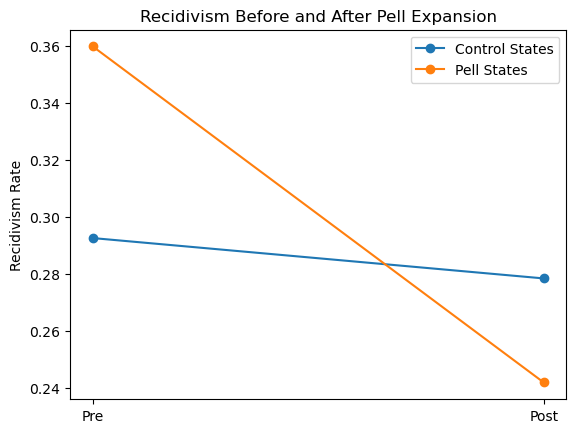

In [17]:
import matplotlib.pyplot as plt

# Use your grouped values directly
pre_control = 0.292563
pre_treated = 0.359699
post_control = 0.278422
post_treated = 0.241961

plt.figure()

plt.plot(
    ["Pre", "Post"], [pre_control, post_control], marker="o", label="Control States"
)
plt.plot(["Pre", "Post"], [pre_treated, post_treated], marker="o", label="Pell States")

plt.title("Recidivism Before and After Pell Expansion")
plt.ylabel("Recidivism Rate")
plt.legend()

plt.show()

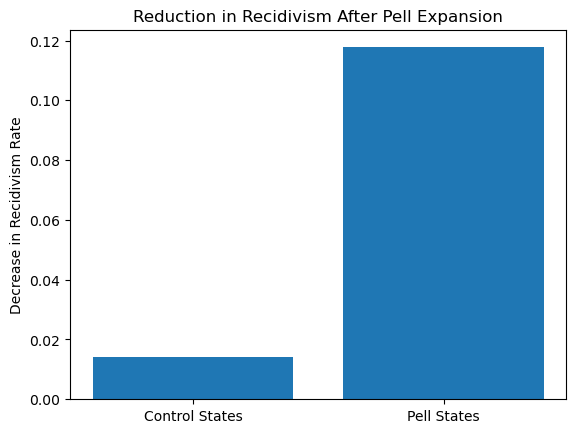

In [18]:
import matplotlib.pyplot as plt

# Values from your data
pre_control = 0.292563
post_control = 0.278422

pre_treated = 0.359699
post_treated = 0.241961

# Compute decreases
control_drop = pre_control - post_control
treated_drop = pre_treated - post_treated

# Plot
labels = ["Control States", "Pell States"]
values = [control_drop, treated_drop]

plt.figure()
plt.bar(labels, values)

plt.title("Reduction in Recidivism After Pell Expansion")
plt.ylabel("Decrease in Recidivism Rate")

plt.show()

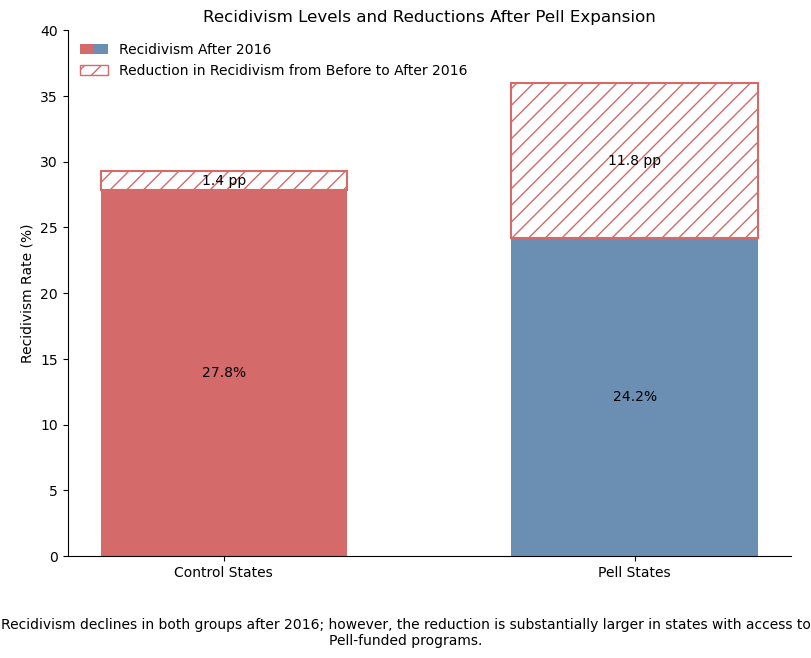

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch, Rectangle
from matplotlib.legend_handler import HandlerBase


class HandlerHalfAndHalf(HandlerBase):
    def create_artists(
        self, legend, orig_handle, x0, y0, width, height, fontsize, trans
    ):
        left = Rectangle(
            (x0, y0),
            width / 2,
            height,
            facecolor=orig_handle[0].get_facecolor(),
            transform=trans,
        )
        right = Rectangle(
            (x0 + width / 2, y0),
            width / 2,
            height,
            facecolor=orig_handle[1].get_facecolor(),
            transform=trans,
        )
        return [left, right]


# data in %
pre_control = 29.2563
post_control = 27.8422

pre_pell = 35.9699
post_pell = 24.1961

control_drop = pre_control - post_control  # 1.4 pp
pell_drop = pre_pell - post_pell  # 11.8 pp

x = np.arange(2)
labels = ["Control States", "Pell States"]

red = "#d46a6a"
blue = "#6b8fb3"

plt.figure(figsize=(8, 6))

# post bars
plt.bar(x[0], post_control, color=red, width=0.6)
plt.bar(x[1], post_pell, color=blue, width=0.6)

# actual drop overlays
plt.bar(
    x[0],
    control_drop,
    bottom=post_control,
    width=0.6,
    hatch="//",
    edgecolor=red,
    color="none",
    linewidth=1.5,
)
plt.bar(
    x[1],
    pell_drop,
    bottom=post_pell,
    width=0.6,
    hatch="//",
    edgecolor=red,
    color="none",
    linewidth=1.5,
)

# labels
plt.text(x[0], post_control / 2, f"{post_control:.1f}%", ha="center", va="center")
plt.text(x[1], post_pell / 2, f"{post_pell:.1f}%", ha="center", va="center")

plt.text(
    x[0],
    post_control + control_drop / 2,
    f"{control_drop:.1f} pp",
    ha="center",
    va="center",
)
plt.text(
    x[1], post_pell + pell_drop / 2, f"{pell_drop:.1f} pp", ha="center", va="center"
)

plt.xticks(x, labels)
plt.ylabel("Recidivism Rate (%)")
plt.title("Recidivism Levels and Reductions After Pell Expansion")
plt.ylim(0, 40)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

recid_handle = (Patch(facecolor=red), Patch(facecolor=blue))
reduction_handle = Patch(facecolor="none", edgecolor=red, hatch="//")

plt.legend(
    [recid_handle, reduction_handle],
    ["Recidivism After 2016", "Reduction in Recidivism from Before to After 2016"],
    handler_map={tuple: HandlerHalfAndHalf()},
    frameon=False,
)

caption = (
    "Recidivism declines in both groups after 2016; however, the reduction is substantially "
    "larger in states with access to Pell-funded programs."
)
plt.figtext(0.5, -0.08, caption, wrap=True, ha="center")

plt.tight_layout()
plt.savefig("Plots/pell_plot_05.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
# print treatment states (PELL_2016 == 1)

treated_states = df.loc[df["PELL_2016"] == 1, "STATE_NAME"].dropna().unique()

print(sorted(treated_states))

['Alabama', 'California', 'Florida', 'Illinois', 'Indiana', 'Iowa', 'Massachusetts', 'Michigan', 'Minnesota', 'Nebraska', 'New Jersey', 'New York', 'Ohio', 'Oklahoma', 'Pennsylvania', 'South Carolina', 'Texas', 'Washington', 'Wisconsin']


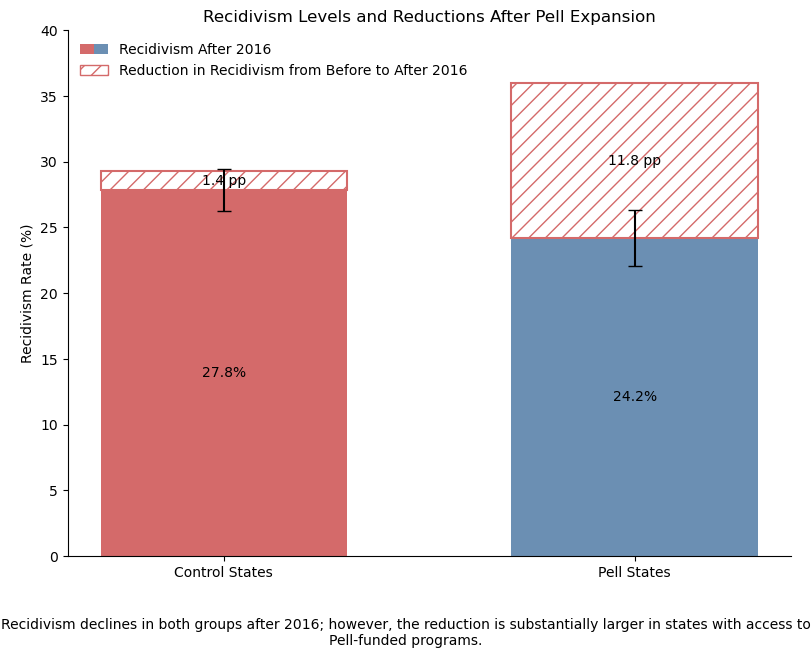

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch, Rectangle
from matplotlib.legend_handler import HandlerBase


class HandlerHalfAndHalf(HandlerBase):
    def create_artists(
        self, legend, orig_handle, x0, y0, width, height, fontsize, trans
    ):
        left = Rectangle(
            (x0, y0),
            width / 2,
            height,
            facecolor=orig_handle[0].get_facecolor(),
            transform=trans,
        )
        right = Rectangle(
            (x0 + width / 2, y0),
            width / 2,
            height,
            facecolor=orig_handle[1].get_facecolor(),
            transform=trans,
        )
        return [left, right]


# =========================
# DATA (%)
# =========================

pre_control = 29.2563
post_control = 27.8422

pre_pell = 35.9699
post_pell = 24.1961

# reductions
control_drop = pre_control - post_control
pell_drop = pre_pell - post_pell

# =========================
# STANDARD ERRORS
# Replace these with actual values from your data
# =========================

se_control = 0.8
se_pell = 1.1

# 95% confidence intervals
ci_control = 1.96 * se_control
ci_pell = 1.96 * se_pell

# =========================
# PLOT SETUP
# =========================

x = np.arange(2)
labels = ["Control States", "Pell States"]

red = "#d46a6a"
blue = "#6b8fb3"

plt.figure(figsize=(8, 6))

# =========================
# POST-2016 BARS
# =========================

plt.bar(
    x[0],
    post_control,
    color=red,
    width=0.6,
)

plt.bar(
    x[1],
    post_pell,
    color=blue,
    width=0.6,
)

# =========================
# ERROR BARS
# =========================

plt.errorbar(
    x[0],
    post_control,
    yerr=ci_control,
    fmt="none",
    ecolor="black",
    capsize=5,
    linewidth=1.5,
)

plt.errorbar(
    x[1],
    post_pell,
    yerr=ci_pell,
    fmt="none",
    ecolor="black",
    capsize=5,
    linewidth=1.5,
)

# =========================
# REDUCTION OVERLAYS
# =========================

plt.bar(
    x[0],
    control_drop,
    bottom=post_control,
    width=0.6,
    hatch="//",
    edgecolor=red,
    color="none",
    linewidth=1.5,
)

plt.bar(
    x[1],
    pell_drop,
    bottom=post_pell,
    width=0.6,
    hatch="//",
    edgecolor=red,
    color="none",
    linewidth=1.5,
)

# =========================
# LABELS INSIDE BARS
# =========================

plt.text(
    x[0],
    post_control / 2,
    f"{post_control:.1f}%",
    ha="center",
    va="center",
)

plt.text(
    x[1],
    post_pell / 2,
    f"{post_pell:.1f}%",
    ha="center",
    va="center",
)

plt.text(
    x[0],
    post_control + control_drop / 2,
    f"{control_drop:.1f} pp",
    ha="center",
    va="center",
)

plt.text(
    x[1],
    post_pell + pell_drop / 2,
    f"{pell_drop:.1f} pp",
    ha="center",
    va="center",
)

# =========================
# AXES / TITLE
# =========================

plt.xticks(x, labels)

plt.ylabel("Recidivism Rate (%)")

plt.title("Recidivism Levels and Reductions After Pell Expansion")

plt.ylim(0, 40)

# remove extra spines
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

# =========================
# LEGEND
# =========================

recid_handle = (Patch(facecolor=red), Patch(facecolor=blue))

reduction_handle = Patch(
    facecolor="none",
    edgecolor=red,
    hatch="//",
)

plt.legend(
    [recid_handle, reduction_handle],
    [
        "Recidivism After 2016",
        "Reduction in Recidivism from Before to After 2016",
    ],
    handler_map={tuple: HandlerHalfAndHalf()},
    frameon=False,
)

# =========================
# CAPTION
# =========================

caption = (
    "Recidivism declines in both groups after 2016; however, the reduction is substantially "
    "larger in states with access to Pell-funded programs."
)

plt.figtext(
    0.5,
    -0.08,
    caption,
    wrap=True,
    ha="center",
)

# =========================
# SAVE + SHOW
# =========================

plt.tight_layout()

plt.savefig(
    "Plot/pell_plot_errorbar.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()